# Python for Finance — Session 4 notebook

**Planning and building a program**

## How to use it

Today we decompose the previous session's exercise into **one task at a time**. Then you practise the same method on three brand new exercises.

```
COMPLEX TASK
    -> PLAN YOUR TASKS
    -> CODE ONE TASK AT A TIME
    -> CHECK EACH IMPORTANT RESULT
    -> COMBINE THE TASKS
```

A **meta-algorithm** is the list of steps you write *before* coding. \
Each step answers/operazionalizes four questions:

- **Input** — what does this step start from?
- **Task** — what does it do?
- **Output** — which object does it create?
- **Check** — how do we know the output is correct? (skip it when no useful check exists)

**How to work today**

- **Part I** (together with the instructor): run the cells in order. When you see **Before running the next cell**, answer the question first.
- **Part II** (your turn): three exercises of about 30 minutes each.\
(Cells marked `None` print "Not attempted yet." until you fill them, so **Run All** always works w/out problems.)

Run the next cell first. It imports the libraries and checks that the `data` folder sits next to this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
PARCEL_PATH = DATA_DIR / "session3_parcel_reliability.csv"
PRICES_PATH = DATA_DIR / "session4_portfolio_prices.csv"

for path in [PARCEL_PATH, PRICES_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"{path.as_posix()} not found: open this notebook from the folder "
            "that contains the 'data' directory."
        )
print("NumPy", np.__version__, "| pandas", pd.__version__)
print("Data files found.")

NumPy 1.26.4 | pandas 3.0.3
Data files found.


## Part I — Decomposing a complex task into smaller tasks

### Exercise A

You have nine employee expense claims.  
For each claim, we know:
- the claim ID;
- the employee who submitted it;
- the expense category;
- the amount claimed;
- whether a receipt was provided.
The information is stored in five lists. The first entry in each list belongs to the first claim, the second entry belongs to the second claim, and so on.\

The reimbursement rules must be applied in the following order:
1. If the amount is zero or negative, *reject* the claim.
2. If the expense category is not included in `category_limits`, *reject* the claim.
3. If the amount is greater than EUR 25, a receipt is *required*. If the receipt is *missing, reject* the claim.
4. *Otherwise, reimburse* the smaller of:
   - the *amount* claimed; and
   - the *maximum amount* allowed for that category.
5. A valid claim is:
   - `approved` if the full amount can be reimbursed;
   - `capped` if the category limit reduces the reimbursement;
   - `rejected` if one of the earlier rules applies.

Your final program should produce:

- one result for each claim, stored in `claim_results` and kept in the original order;
- the total amount reimbursed to each employee, stored in `totals_by_employee`;
- the number of rejected claims for each employee, stored in `rejected_by_employee`;
- the employee who receives the largest total reimbursement;
- an ordered list, `review_ids`, containing the IDs of all capped or rejected claims;
- (a few checks confirming that the final results are consistent)

In this session, we will slow the process down and build the solution one step at a time.

In [2]:
claim_ids = ["C101", "C102", "C103", "C104", "C105",
             "C106", "C107", "C108", "C109"]
employees = ["Amina", "Leo", "Amina", "Marta", "Leo",
             "Marta", "Amina", "Leo", "Marta"]
categories = ["train", "meal", "hotel", "taxi", "hotel",
              "meal", "meal", "train", "hotel"]
amounts = [145.0, 42.0, 260.0, 30.0, 180.0,
           -5.0, 18.0, 210.0, 130.0]
has_receipt = [True, True, True, True, False,
               True, False, True, True]

category_limits = {"train": 160.0, "meal": 35.0, "hotel": 200.0}

### 1.1 Read the question: what do we start from, and what must we produce?

Before writing any code, identify two things:

1. What information has already been given to us?
2. What results are we expected to produce?

**What information do we start from?**

We have:

- five lists containing the information about the nine claims;
- one dictionary (i.e., `category_limits`), that tells us the max amount that can be reimbursed for each expense category.

The five lists are connected by their position. The first entry in each list belongs to the first claim, the second entry belongs to the second claim, and so on.

**What must we produce?**

| Output | What it contains | Level |
|---|---|---|
| `claim_results` | a list containing one dictionary for each claim, kept in the original order | one result per **claim** |
| `totals_by_employee` | the total reimbursement received by each employee | one result per **employee** |
| `rejected_by_employee` | the number of rejected claims for each employee | one result per **employee** |
| employee with the largest total | the employee's name and total reimbursement | one final answer |
| `review_ids` | the IDs of all capped or rejected claims, kept in the original order | one final list |

Why dictionary per each claim? A dictionary is a good choice as each claim has several pieces of information with different meanings, and later we can write something like `result["employee"]` rather than, say, `result[1]` (list/tuple).

Notice that the required results are not all calculated altogether.

First, we need to decide what happens to **each individual claim**.

Only after those decisions have been made can we combine the results and calculate the totals for **each employee**.

This already suggests the structure of our program:

1. process the claims one by one;
2. store the result of each claim;
3. use those completed results to build the employee summaries and the final outputs.

### 1.2 Plan the solution before writing the code

Before we start coding, let us break the problem into smaller tasks.\
This is our **meta-algorithm**: a plan of what the program needs to do, in the order in which it should do it.

---

**Step 1 — Check the input data**

**Input:**\
the five lists containing the claim information.

**What do we do?**\
Before using the lists together, check that they are consistent.
In particular:
- all five lists should have the same length;
- each claim ID should appear only once.

If these checks pass, we can safely treat the entries in the same position as belonging to the same claim.

**Output:** nothing new.

---

**Step 2 — Decide what happens to a claim**

**Input:**\
one claim: its category, amount and receipt information, together with `category_limits`.

**What do we do?**  
Apply the reimbursement rules/policy, in the correct sequence, to this representative claim.

**Output:**

- one `status`;
- one reimbursed amount.

For the moment, we are not thinking about all nine claims.  
We first want to make sure that we can decide **one claim correctly**.

---

**Step 3 — Test our decision on a few simple cases**

**Input:** the function created in Step 2 and one (or two) claims whose answers we can work out by hand.

**What do we do?**  
Run the function on these simple examples before (looping) using it on the full dataset.

**Output:** does Python give the same answer that we obtained by hand?

This is a quick way to catch mistakes in the decision rules before repeating mistakes nine times.

---

**Step 4 — Apply the decision to all nine claims**

**Input:** the five input lists and the function from Step 2.

**What do we do?**  
Go through the claims one by one, in their original order. For each claim:

1. apply the decision function;
2. store the result.

**Output:** `claim_results`, a list containing one dictionary for each of the 9 claims.

Each dictionary will contain four pieces of information:

- the claim ID;
- the employee;
- the status;
- the reimbursed amount.

**We check:**

- `claim_results` contains 9 records;
- the claim IDs are still in the same order as `claim_ids`;
- every record contains the four expected pieces of information.

---

**Step 5 — Summarise the results for each employee**

**Input:** the completed `claim_results`.

**What do we do?**  
Use the individual claim results to calculate, for each employee:

- the total amount reimbursed;
- the number of rejected claims.

**Output:**

- `totals_by_employee`;
- `rejected_by_employee`.

**We check:** the reimbursements in `totals_by_employee` should add up to the same total as the reimbursements in `claim_results`.

---

**Step 6 — Produce the final answer**

**Input:** the claim records and the employee summaries that we have already built.

**What do we do?**

- find the employee with the largest total reimbursement;
- collect the IDs of all claims that were `capped` or `rejected`.

**Output:**

- `top_employee`;
- `top_total`;
- `review_ids`.

**We check:** the IDs in `review_ids` should appear in the same order as the original claims.

**Step 7 — Check that the final results are consistent**

**Input:** the results we have already calculated.

**What do we do?**  
Calculate important totals in more than one way and check that they agree.

For example, the total reimbursement calculated from the individual claims should be the same as the total calculated from the employee summaries.

**Output:** nothing new (hopefully).

### 1.3 Which Python tools can help us with each step?

We now have a plan for the solution. The next question is:

**Which Python tools do we already know that can carry out each part of that plan?**

Most of what we need comes directly from Session 1.

| Step | What do we need to do? | Python tool | Why is it useful here? |
|---|---|---|---|
| 1 | Check that the lists have the same length and that claim IDs are unique | `len()`, `set()`, `assert` | `len()` lets us compare the sizes of the lists. A `set` keeps each distinct ID only once, so it helps us detect duplicates. `assert` checks that a condition we expect to be true is actually true. |
| 2 | Apply the reimbursement rules to one claim, in the prespecified sequence | a function with `if / elif / else` and `return` | `if / elif / else` lets us check the rules in sequence. Once one condition is satisfied, the corresponding branch is used. `return` gives us the result so that we can store and use it later. |
| 4 | Go through the five lists together, one claim at a time | `zip()` and a `for` loop | `zip()` brings together the entries that occupy the same position in the five lists. The `for` loop then lets us process one claim at a time. |
| 4 | Store the result of each claim | a dictionary inside a list, using `.append()` | The dictionary gives a name to each piece of information, such as `"status"` or `"reimbursed"`. The list keeps the claim records in their original order. |
| 5 | Calculate totals and rejection counts for each employee | dictionaries and a `for` loop | The employee's name can be used as the dictionary key. As we move through the claim results, we update that employee's total or count. |
| 6 | Find the employee with the largest reimbursement total | a `for` loop over `.items()` | We can compare the employee totals one by one and keep track of the largest value found so far. |
| 6 | Keep only the IDs of claims that need review | a list comprehension with `if` | The condition selects only the `capped` or `rejected` claims, while the list preserves their original order. |
| 7 | Check that different parts of the solution agree | `assert` and `sum()` | `sum()` lets us calculate totals in two different ways, and `assert` checks that the two answers agree. |

We first decide what the task requires, and then choose from the tools we already know.

### 1.3 Step 1 — Verify the inputs

Using `assert`, `len()` and `set()`, verify that the five lists have the same length and that the claim IDs are unique.

In [3]:
n_claims = len(claim_ids)

assert len(employees) == n_claims
assert len(categories) == n_claims
assert len(amounts) == n_claims
assert len(has_receipt) == n_claims
assert len(set(claim_ids)) == n_claims     # a set keeps each ID once

print("Inputs are aligned:", n_claims, "claims, all IDs unique.")

Inputs are aligned: 9 claims, all IDs unique.


We now understand how the five lists fit together: the entries in the same position describe the same claim.

The final program must make a decision for every claim. But before repeating the process nine times, we should first make sure that we can decide **one claim correctly**.

### 1.4 Step 2 — Decide about one claim

We will create a function:

```python
assess_claim(category, amount, receipt, limits)

In [4]:
def assess_claim(category, amount, receipt, limits):
    """Return (status, reimbursed) for one claim, applying the rules in order."""
    if amount <= 0:
        return "rejected", 0.0
    elif category not in limits:              # checks the keys of the dictionary
        return "rejected", 0.0
    elif amount > 25 and not receipt:
        return "rejected", 0.0
    elif amount > limits[category]:
        return "capped", limits[category]
    else:
        return "approved", amount

The order of the `if / elif` conditions matters because it reproduces the order of the reimbursement rules. Python checks the conditions from top to bottom. As soon as one condition is true, that branch is used and the remaining `elif` conditions are skipped.

Example: for C106, the amount is negative.\
--> The claim is therefore rejected immediately and never reaches the reimbursement calculation.

### 1.5 Step 3 — Test the claim classifying function before looping

We have written a function that decides one claim (at a time).\
Before applying it to all nine claims, we should check that it behaves as expected.

Start with two claims from the dataset:

- C101, at position `0`;
- C104, at position `3`.

Before running the function, work out each answer by hand.\
Then compare your answer with what Python returns.

After these simple checks, test a few cases where mistakes are especially easy to make.

In particular, check:

- a **negative amount**: it should be rejected immediately;
- an amount of **exactly EUR 25 without a receipt**: the receipt rule applies only when the amount is greater than EUR 25;
- a valid amount that is **above the category limit**: the claim should be capped at the maximum reimbursement.

We can use `assert` for these checks: i) if it is true, Python continues; ii) if it is false, Python stops and tells us that one of our expectations was not satisfied.

Testing the function now is much easier than discovering a mistake after we have already used it on all nine claims

In [5]:
print("C101:", assess_claim(categories[0], amounts[0], has_receipt[0], category_limits))
print("C104:", assess_claim(categories[3], amounts[3], has_receipt[3], category_limits))

assert assess_claim("train", 145.0, True, category_limits) == ("approved", 145.0)   # C101
assert assess_claim("taxi", 30.0, True, category_limits) == ("rejected", 0.0)       # C104: unknown category
assert assess_claim("meal", -5.0, True, category_limits) == ("rejected", 0.0)       # C106: rule 1 first
assert assess_claim("meal", 25.0, False, category_limits) == ("approved", 25.0)     # 25 is not "greater than 25"
assert assess_claim("hotel", 260.0, True, category_limits) == ("capped", 200.0)     # C103
print("One-claim tests passed.")

C101: ('approved', 145.0)
C104: ('rejected', 0.0)
One-claim tests passed.


We can now decide one claim correctly, and we have tested that decision. The final report, however, needs a result for **all nine claims**. So the next step is to repeat the same decision for every claim and store each result as we go.

**Before running the next cell, think about this:**

What object should the loop build? What should **one element** of that object contain?

### 1.6 Step 4 — Repeat the decision for all claims

We will now apply `assess_claim()` to all nine claims.

The five input lists are aligned: the entries in the same position belong to the same claim. For example, position `0` across the five lists gives us all the information about the first claim:

```python
claim_ids[0]
employees[0]
categories[0]
amounts[0]
receipts[0]
```

Using `zip()`, we can proceed together the information for one claim at a time, since it groups together the values that occupy the same position in several lists. A `for` loop can then repeat the same steps for every claim.

For each claim, we will:

1. call `assess_claim()` to obtain the `status` and `reimbursed` amount;
2. create one dictionary containing:
   - `claim_id`;
   - `employee`;
   - `status`;
   - `reimbursed`;
3. append that dictionary to `claim_results`.

The final object will therefore be a **list of dictionaries**, where i) the list keeps the claims in their original order, and ii) each dictionary gives a clear name to the information stored for one claim. For example, one element of `claim_results` will have the form:

```python
{
    "claim_id": "C101",
    "employee": "Amina",
    "status": "approved",
    "reimbursed": 20
}
```

In [6]:
claim_results = []

for claim_id, employee, category, amount, receipt in zip(
        claim_ids, employees, categories, amounts, has_receipt):
    status, reimbursed = assess_claim(category, amount, receipt, category_limits)
    claim_results.append({
        "claim_id": claim_id,
        "employee": employee,
        "status": status,
        "reimbursed": reimbursed,
    })

claim_results[:2]

[{'claim_id': 'C101',
  'employee': 'Amina',
  'status': 'approved',
  'reimbursed': 145.0},
 {'claim_id': 'C102',
  'employee': 'Leo',
  'status': 'capped',
  'reimbursed': 35.0}]

Check the loop's output before using it: one record per claim, the same order as the input, the four required keys.

In [7]:
assert len(claim_results) == n_claims
assert [result["claim_id"] for result in claim_results] == claim_ids   # same order

for result in claim_results:
    assert set(result) == {"claim_id", "employee", "status", "reimbursed"}
    print(result["claim_id"], result["employee"], result["status"], result["reimbursed"])

C101 Amina approved 145.0
C102 Leo capped 35.0
C103 Amina capped 200.0
C104 Marta rejected 0.0
C105 Leo rejected 0.0
C106 Marta rejected 0.0
C107 Amina approved 18.0
C108 Leo capped 160.0
C109 Marta approved 130.0


We now have one completed record for each claim.

The next questions, however, are about **employees**, not individual claims.

So we now move from the **claim level** to the **employee level**: instead of one record per claim, we want one summary for each employee (e.g., different claims same employee).

### 1.7 Step 5 — Summarise by employee

We will build two dictionaries:

- `totals_by_employee`, containing the total amount reimbursed to each employee;
- `rejected_by_employee`, containing the (integer) number of rejected claims for each employee.

We use the **employee name as the dictionary key** because each employee should have one total reimbursement and one rejection count.

For example:

```python
totals_by_employee = {
    "Amina": 180,
    "Leo": 95
}

In [8]:
totals_by_employee = {}
rejected_by_employee = {}

for result in claim_results:
    name = result["employee"]
    if name not in totals_by_employee:          # first claim of this employee
        totals_by_employee[name] = 0.0
        rejected_by_employee[name] = 0
    totals_by_employee[name] += result["reimbursed"]
    if result["status"] == "rejected":
        rejected_by_employee[name] += 1

print(totals_by_employee)
print(rejected_by_employee)

{'Amina': 363.0, 'Leo': 195.0, 'Marta': 130.0}
{'Amina': 0, 'Leo': 1, 'Marta': 2}


**Check.** Compute the same total twice, once from the claims and once from the employees, to see if they match and no claim has been lost.

In [9]:
claim_level_total = sum([result["reimbursed"] for result in claim_results])
employee_level_total = sum(totals_by_employee.values())
n_rejected = len([result for result in claim_results if result["status"] == "rejected"])

assert claim_level_total == employee_level_total
assert sum(rejected_by_employee.values()) == n_rejected
print("claim-level total:", claim_level_total, "| employee-level total:", employee_level_total)

claim-level total: 688.0 | employee-level total: 688.0


We now have all the information we need.

The two remaining management questions can be answered using objects that already exist. We do **not** need to go back to the original five lists and process the claims again.

### 1.8 Step 6 — Answer the management questions

There are two final questions to answer.

**1) Which employee received the largest total reimbursement?**

We already have the answer inside `totals_by_employee`. We can loop through:

```python
totals_by_employee.items()
```

`.items()` gives us both parts of each dictionary entry:
- the employee name;
- that employee's total reimbursement.

As we move through the dictionary, we keep track of the largest total we have seen so far and the employee associated with it. At the end of the loop, we will have:

- `top_employee`;
- `top_total`.


**2) Which claims need to be reviewed?**

A claim needs review if its status is either:

- `capped`;
- `rejected`.

That information is already stored in `claim_results`. We can therefore use a list comprehension with an `if` condition to keep only the IDs of claims whose status requires review. The result will be stored in:

```python
review_ids
```

Why do we use a **list** rather than a set?

Because the claims should remain in the same order as the original input. A list preserves that order, while a set is designed to store unique values rather than preserve the sequence in which the claims appeared. The important idea is that we are now answering the final questions from the objects we have already built, rather than starting again from the raw input data.

In [10]:
top_employee = None
top_total = -1.0                         # every total is >= 0, so the first employee replaces this
for name, total in totals_by_employee.items():
    if total > top_total:
        top_employee = name
        top_total = total
print("largest total:", top_employee, top_total)

review_ids = [result["claim_id"] for result in claim_results
              if result["status"] in ("capped", "rejected")]
print("claims to review:", review_ids)

assert review_ids == [claim_id for claim_id in claim_ids if claim_id in review_ids]   # input order

largest total: Amina 363.0
claims to review: ['C102', 'C103', 'C104', 'C105', 'C106', 'C108']


### 1.9 Step 7 — Reconcile with the expected results

These are the expected results. Each assertion compares one of our objects with them.

In [11]:
EXPECTED_RESULTS = [
    ("C101", "Amina", "approved", 145.0), ("C102", "Leo", "capped", 35.0),
    ("C103", "Amina", "capped", 200.0), ("C104", "Marta", "rejected", 0.0),
    ("C105", "Leo", "rejected", 0.0), ("C106", "Marta", "rejected", 0.0),
    ("C107", "Amina", "approved", 18.0), ("C108", "Leo", "capped", 160.0),
    ("C109", "Marta", "approved", 130.0),
]
EXPECTED_TOTALS = {"Amina": 363.0, "Leo": 195.0, "Marta": 130.0}
EXPECTED_REJECTED = {"Amina": 0, "Leo": 1, "Marta": 2}
EXPECTED_REVIEW = ["C102", "C103", "C104", "C105", "C106", "C108"]

as_tuples = [(r["claim_id"], r["employee"], r["status"], r["reimbursed"]) for r in claim_results]
assert as_tuples == EXPECTED_RESULTS
assert totals_by_employee == EXPECTED_TOTALS
assert rejected_by_employee == EXPECTED_REJECTED
assert review_ids == EXPECTED_REVIEW
assert (top_employee, top_total) == ("Amina", 363.0)
assert claim_level_total == 688.0
print("All Session-3 results reproduced.")

All Session-3 results reproduced.


### 1.10 Another way to tackle the same problem.

The proposed solution is not unique. The **reimbursement rules do not change**, and the final outputs do not change. What can change is the order in which we build those outputs.
There are two natural approaches.

---

**Route A — update the summaries as we go**

For each claim:

1. decide the claim using `assess_claim()`;
2. store its result in `claim_results`;
3. immediately update that employee's reimbursement total and rejection count.

In this approach, the claim-level results and the employee-level summaries are built together inside the same loop.

---

**Route B — build the claim results first, then summarise them**

This is the approach of the proposed solution, that is splitting the loops.

First:

1. decide all nine claims;
2. store all nine results in `claim_results`.

Then, in a separate step:

3. loop through `claim_results`;
4. calculate the totals and rejection counts for each employee.

This separates the two levels of the problem:

**claims first → employees second**

---

Both approaches are valid and should produce the same final results.

For this exercise, Route B is useful because it makes the decomposition especially clear: we first make sure that every individual claim has been decided correctly, and only then use those completed results to build the employee summaries.

The code below shows Route A, where the same work is organised in a single loop.

In [12]:
claim_results_a = []
totals_a = {}
rejected_a = {}

for claim_id, employee, category, amount, receipt in zip(
        claim_ids, employees, categories, amounts, has_receipt):
    status, reimbursed = assess_claim(category, amount, receipt, category_limits)
    claim_results_a.append({"claim_id": claim_id, "employee": employee,
                            "status": status, "reimbursed": reimbursed})
    if employee not in totals_a:
        totals_a[employee] = 0.0
        rejected_a[employee] = 0
    totals_a[employee] += reimbursed
    if status == "rejected":
        rejected_a[employee] += 1

assert claim_results_a == claim_results
assert totals_a == totals_by_employee and rejected_a == rejected_by_employee
print("Route A and Route B agree.")

Route A and Route B agree.


The two routes:

| | Route A: update as you go | Route B: build first, then summarise |
|---|---|---|
| Number of processing stages | one main loop | one loop to build the claim records, then another to summarise them |
| Intermediate results | fewer separate objects to inspect | `claim_results` is complete before we start the employee summaries |
| If something is wrong | the same loop is making the claim decision, storing the result, and updating the employee summaries | we can check Step 4 first; if the claim records are correct, then check Step 5 |

### 2. Parcel reliability: dissecting it into smaller tasks

An operations manager wants to compare how reliably parcels are delivered across two regions (i.e., North/South).

The dataset contains one row for each combination of:

- date;
- depot;
- service type.

For each row, we know: i) the total number of parcels recorded, and ii) the number of parcels delivered late.

Since a parcel that is late, by definition, has not been delivered on time,\
--> A parcel that is not late is considered to have been delivered on time.\
We can therefore calculate reliability as:

`on-time rate = (recorded parcels - late parcels) / recorded parcels`

There is one important complication: for some rows, the total number of recorded parcels is unavailable.

Without that total, we do not know the denominator of the reliability rate, so those rows cannot be used to calculate it.

The manager wants us to answer two questions:

1. How reliable is each service within each region?
2. For the express service, how did reliability change from day to day in each region?

For the daily express comparison, the manager uses **92%** as a reference level.

The dataset contains *depot IDs rather than region names*, so we are also given a small lookup table that tells us which region each depot belongs to.

In [13]:
depots = pd.DataFrame({
    "depot_id": ["D01", "D02", "D03", "D04"],
    "region": ["North", "North", "South", "South"],
})
depots

,depot_id,region
0,D01,North
1,D02,North
2,D03,South
3,D04,South


### 2.1 Work backwards from the final answer

For this kind of data problem, it is often helpful to start from the **final output** and ask:

**What must already exist before we can produce it?**

For the daily express figure, the reasoning is:

1. The figure needs a table with **one row per date and one column per region**, containing the express on-time rates.
2. To calculate one on-time rate for a group — for example, one date and one region — we first need:
   - the total number of on-time parcels in that group;
   - the total number of recorded parcels in that group.
3. To calculate those totals, every usable row must already contain:
   - a numeric parcel count;
   - an on-time parcel count;
   - a region.
4. To obtain a numeric parcel count, we first need to deal with rows where the parcel total is recorded as `not_recorded`.
5. To have a region on every row, we need to attach the depot-to-region information from the `depots` table.

If we now read the list **from Step 5 back to Step 1**, we obtain the order in which the program should work:

**clean the parcel totals → attach the regions → calculate on-time parcels → group and sum → calculate rates → reshape for the figure**

Working backwards from the final output helps us see which intermediate objects we need before we start writing code.

### 2.2 Plan the tasks (meta-algorithm)

---

**Step 1 — Load the data and inspect it**

**Input:**\
the CSV file.

**What do we do?**  
Load the file and look at the data before trying to calculate anything:

- how many rows and columns there are;
- what each column contains;
- which data types Python has assigned to the columns;
- why `parcels` has not been read as a numeric column.

**Output:**\
`raw`, the dataset as it was read from the CSV file.

**We check:** `raw` should contain 224 rows and 6 columns, and the inspection should reveal the `not_recorded` values in `parcels`.

---

**Step 2 — Make the parcel counts usable**

**Input:**\
`raw`.

**What do we do?**

Convert `parcels` to a numeric column. The value `not_recorded` cannot be converted to a parcel count, so we represent it as missing: we keep only the rows for which a parcel total is actually available.

**Output:**

- `repaired`, where `parcels` has been converted to numeric values;
- `analysis`, containing only rows with a recorded parcel count.

**We check:**

- there are 6 rows with an unavailable parcel count;
- `analysis` therefore contains `224 - 6 = 218` rows;
- `parcels` contains no missing values in `analysis`.

---

**Step 3 — Add the region of each depot**

**Input:**\
`analysis` and the `depots` lookup table.

**What do we do?**  
Use the depot ID to attach the corresponding region to every delivery observation.

**Output:**\
`with_region`, which contains the original analysis data *together* with a `region` column.

**We check:**

- the number of rows is still 218;
- every row has a region;
- the merge has neither lost nor unexpectedly duplicated observations.

---

**Step 4 — Calculate the number of on-time parcels**

**Input:** `with_region`.

**What do we do?**  
For each row, calculate:

```python
on_time = parcels - late_parcels
```

**Output:** a new `on_time` column.

**We check:**
(implicitly the measure is supposed to be:)
- `on_time` should be never negative;
- `on_time` should be never greater than `parcels`.

---

**Step 5 — Add up the parcel counts for each region and service**

**Input:** `with_region`.

**What do we do?**  
Group the observations by region and service. Within each group, calculate:

- the total number of recorded parcels;
- the total number of late parcels;
- the total number of on-time parcels;
- the number of rows/obs contributing to the group.

**Output:** `summary`, with one row for each region–service combination.

Since there are two-regions-by-two-service types, `summary` should contain (2x2=)4 rows.

**We check:** the numbers of obs across the four groups should add up to the 218 rows in `with_region`.

---

**Step 6 — Calculate the reliability rate for each region and service**

**Input:** `summary`.

**What do we do?**  
For each region–service group, calculate the on-time rate from the **grouped parcel totals**:

```python
on_time_rate = total on-time parcels / total recorded parcels
```

We calculate the rate **after** summing the parcel counts. We do not average row-level percentages.

**Output:** an `on_time_rate` column in `summary`.

**We check:** every rate is between `0` and `1`.

---

**Step 7 — Build the daily express reliability table**

**Input:** `with_region`.

**What do we do?**

1. keep only the rows *for the express service*;
2. *group* them by date and region;
3. *sum* the recorded and on-time parcels within each date–region group;
4. calculate one on-time rate for each date and region;
5. *reshape* the results so that dates are rows and regions are columns.

**Output:**

- `express`, containing only express observations;
- `express_daily`, containing one row for each date–region combination;
- `daily_express`, with dates in the rows and regions in separate columns.

**We check:** before reshaping, `express_daily` should contain one row for each date–region combination.

---

**Step 8 — Check the daily express results**

**Input:** `daily_express`.

**What do we do?**

Check that the final daily table has the expected structure and valid values.\
Count, for each region, how many days have an on-time rate below the manager's threshold of 92%.

**Output:** `days_below_92`.

**We check:**

- `daily_express` has 28 rows and 2 regional columns;
- there are no missing values;
- every on-time rate is between `0` and `1`.

---

**Step 9 — Create the figure**

**Input:** `daily_express`.

**What do we do?**

Plot:

- one daily reliability line for each region;
- one horizontal line at `0.92` to show the manager's reference level.

**Output:** `fig` and `ax`.

**We check:** the final figure contains three lines: two regional reliability series and the 92% reference line.

### 2.3 Which Python tools can help us with each step?

We now have a plan for the analysis. The next question is:

**Which Python tools do we already know that can carry out each part of that plan?**

All the tools below were introduced in Session 2.

| Step | What do we need to do? | Python tool | Why is it useful here? |
|---|---|---|---|
| 1 | Load the dataset and inspect it | `pd.read_csv(..., parse_dates=["date"])`, `.shape`, `.dtypes`, `.head()` | Before calculating anything, we want to see the table, check its size, and understand how Python has read each column. |
| 2 | Convert parcel counts to numbers and deal with `not_recorded` | `pd.to_numeric(..., errors="coerce")`, `.dropna(subset=...)` | `errors="coerce"` converts values that cannot be read as numbers into `NaN`. We can then remove only the rows where the parcel count is unavailable. |
| 3 | Add the region from the depot lookup table | `.merge(..., how="left", validate="many_to_one")` | Many delivery observations can belong to the same depot, while each depot should correspond to one region. The merge attaches that region to every matching observation. |
| 4 | Calculate on-time parcels from two existing columns | column arithmetic | Pandas can subtract one whole column from another, so we do not need a loop over the rows. |
| 5 | Calculate totals for each region–service group | `.groupby([...]).agg(...)` | `groupby` separates the observations into groups, and `agg` calculates the required totals inside each group. |
| 6 | Calculate one reliability rate for each group | division of two columns | Once the parcel counts have been summed, we divide total on-time parcels by total recorded parcels. The division comes **after** the aggregation. |
| 7 | Keep only express observations | `.loc[condition]` | A Boolean condition allows us to select only the rows that satisfy the condition we want. |
| 7 | Reshape the daily results from long to wide format | `.pivot()` / `.pivot_table()` | We want dates in the rows and regions in separate columns. These methods reshape the table into that form. |
| 8 | Check the final daily table | `.shape`, `.isna()`, `np.isfinite`, comparisons | These tools let us check the size of the table, look for missing or non-finite values, and verify that every rate is between `0` and `1`. |
| 9 | Create the figure | `fig, ax = plt.subplots()`, `ax.plot()`, `ax.axhline()` | We create one set of axes, draw one line for each regional series, and add the 92% reference line. |

We first decide **what the data task requires**, and then choose the appropriate tool from the ones we already know.

### 2.3 Step 1 — Load and inspect

Using `pd.read_csv`, load the file. Parse the dates while loading with `parse_dates=["date"]`. Then look at the shape, the dtypes and the first rows.

In [14]:
raw = pd.read_csv(PARCEL_PATH, parse_dates=["date"])

print("rows, columns:", raw.shape)
print(raw.dtypes)
raw.head()

rows, columns: (224, 6)
date            datetime64[us]
depot_id                   str
service                    str
parcels                    str
late_parcels             int64
driver_hours           float64
dtype: object


,date,depot_id,service,parcels,late_parcels,driver_hours
0,2026-04-06,D01,standard,114,10,10.61
1,2026-04-06,D01,express,84,10,7.99
2,2026-04-06,D02,standard,126,7,11.90
3,2026-04-06,D02,express,96,0,9.28
4,2026-04-06,D03,standard,114,10,11.01


`parcels` is read as text, not as a number. Using `.loc[]` and `.str.isnumeric()`, show the rows whose `parcels` value is not made of digits.

In [15]:
not_digits = ~raw["parcels"].str.isnumeric()
print("rows that are not numbers:", not_digits.sum())
raw.loc[not_digits]

rows that are not numbers: 6


,date,depot_id,service,parcels,late_parcels,driver_hours
19,2026-04-08,D02,express,not_recorded,6,9.83
54,2026-04-12,D04,standard,not_recorded,5,11.01
88,2026-04-17,D01,standard,not_recorded,9,11.19
125,2026-04-21,D03,express,not_recorded,10,7.80
162,2026-04-26,D02,standard,not_recorded,5,10.72
199,2026-04-30,D04,express,not_recorded,6,10.20


We have identified the problem: some rows contain the text `not_recorded` instead of a parcel count. But we need numeric values. Before we can calculate anything, we therefore need to repair the `parcels` column.

### 2.4 Step 2 — Repair the parcel counts and keep the usable rows

We start from `raw`. First, convert `parcels` to a numeric column using:

```python
pd.to_numeric(..., errors="coerce")
```

The option `errors="coerce"` tells pandas: *if a value cannot be converted to a number, replace it with `NaN`.* So the entries equal to `not_recorded` become missing values. We then keep only the rows for which a parcel count is actually available:

```python
dropna(subset=["parcels"])
```

This gives us the rows that can be used to calculate reliability.

Why do we not replace `not_recorded` with `0`?

The correct approach is therefore:

**unavailable parcel count → missing value → exclude that row from calculations that require the parcel total.**

In [16]:
repaired = raw.copy()
repaired["parcels"] = pd.to_numeric(repaired["parcels"], errors="coerce")
n_missing = repaired["parcels"].isna().sum()
print("missing parcel counts:", n_missing)

analysis = repaired.dropna(subset=["parcels"]).copy()
analysis["parcels"] = analysis["parcels"].astype(int)   # counts are whole numbers

assert len(analysis) == len(raw) - n_missing
assert analysis["parcels"].notna().all()
print("rows kept:", len(analysis))

missing parcel counts: 6
rows kept: 218


**Another option from Session 2**

We could also tell pandas about the missing-value marker while loading the file:

```python
pd.read_csv(..., na_values=["not_recorded"])
```

In that case, `not_recorded` would be converted to `NaN` immediately. Here, however, we keep the steps separate on purpose: first we inspect the original data and identify the problem, and only then do we repair it. This makes the cleaning decision easier to understand.

At this point, every row in `analysis` has a usable numeric parcel count. But we still do not know the **region** of each observation. The manager's questions are about regional performance, so our next task is to attach the region associated with each depot.

### 2.5 Step 3 — Attach the region

We have two tables:

- `analysis`, containing the delivery observations and their depot IDs;
- `depots`, containing the region associated with each depot.

We want to use the depot ID to add the corresponding `region` to every row in `analysis`: `merge()`.

We use:

```python
how="left"
```

because `analysis` is the table we want to preserve: every delivery observation should remain in the result, while pandas looks for the matching depot in the lookup table and adds its region.

We also use:

```python
validate="many_to_one"
```

because the relationship should have a very specific structure:

- **many** delivery observations may belong to the same depot;
- each depot should belong to **one** region only.

For example, depot `D01` may appear in *many rows* of `analysis`, but in the `depots` table it should have *only one regional assignment*.

`validate="many_to_one"` asks pandas to check that this assumption is actually true.

If the lookup table contains more than one region for the same depot, pandas raises an error instead of silently performing a merge that does not match the structure we expect.

After the merge, we will have `with_region`: the delivery observations together with their corresponding region.

We should then check that:

- the number of rows has not changed;
- every observation has found a matching region.

In [17]:
with_region = analysis.merge(depots, on="depot_id", how="left", validate="many_to_one")

assert len(with_region) == len(analysis)          # no row lost or duplicated
assert with_region["region"].notna().all()         # every depot found a region
print("rows:", len(with_region))
with_region.head(3)

rows: 218


,date,depot_id,service,parcels,late_parcels,driver_hours,region
0,2026-04-06,D01,standard,114,10,10.61,North
1,2026-04-06,D01,express,84,10,7.99,North
2,2026-04-06,D02,standard,126,7,11.90,North


### 2.6 Step 4 — On-time parcels

The rate needs on-time parcels. Add the column by subtracting two columns (no loop needed).

In [18]:
with_region["on_time_parcels"] = with_region["parcels"] - with_region["late_parcels"]

assert (with_region["on_time_parcels"] >= 0).all()
assert (with_region["on_time_parcels"] <= with_region["parcels"]).all()
with_region.head(3)

,date,depot_id,service,parcels,late_parcels,driver_hours,region,on_time_parcels
0,2026-04-06,D01,standard,114,10,10.61,North,104
1,2026-04-06,D01,express,84,10,7.99,North,74
2,2026-04-06,D02,standard,126,7,11.90,North,119


Every row now contains the information needed to measure reliability:

- (recorded parcels;)
- late parcels;
- on-time parcels;
- region (N vs. S);
- service (express vs. standard).

The manager's first question is about **region–service groups**, not individual rows. So the next step is to combine the observations that belong to the same region and service.

**Before running the next cell, think about this:**

Should we:

1. calculate an on-time rate for every row and then average those rates;

or

2. first add up the parcel counts within each group and then calculate one rate from the grouped totals?

The correct approach is the second one!

### 2.7 Step 5 — Add up the counts for each region and service

We start from `with_region`. We want one row for each combination of:
- `region`;
- `service`.
Thus, we need to use:

```python
groupby(["region", "service"])
```
Within each group, we then calculate:

- the total number of recorded parcels;
- the total number of late parcels;
- the total number of on-time parcels;
- the number of observations contributing to the group.

We can do this using **named aggregation** with `.agg(...)`.
The result is `summary`, with one row for each region–service combination.

Since there are two regions and two service types, we expect:

```python
2 regions × 2 services = 4 rows
```

Why do we sum the parcel counts **before** calculating the rate?

Suppose one observation contains 10 parcels (10 parcels all on time, 100%) and another contains 90 parcels (72 parcels on time, 80%). If we calculated a percentage for each row and then took a simple average, the 10-parcel observation and the 90-parcel observation would receive the same weight. But they represent very different numbers of parcels.

Instead, reliability for a group should answer the following question:

**Of all the parcels recorded in this group, what fraction were delivered on time?**

So we first calculate the grouped totals. The reliability rate itself will be calculated in the next step. After building `summary`, we should also check that the observation counts across the four groups add up to the 218 rows in `with_region`.

In [70]:
summary = (with_region.groupby(["region", "service"])
                      .agg(recorded_parcels=("parcels", "sum"),
                           late_parcels=("late_parcels", "sum"),
                           on_time_parcels=("on_time_parcels", "sum"),
                           rows=("parcels", "size"))
                      .reset_index())

assert summary["rows"].sum() == len(with_region)
assert summary["recorded_parcels"].sum() == with_region["parcels"].sum()
summary
# assert summary["rows"].sum() == 218

,region,service,recorded_parcels,late_parcels,on_time_parcels,rows
0,North,express,4785,289,4496,55
1,North,standard,6604,566,6038,54
2,South,express,4412,335,4077,54
3,South,standard,6454,646,5808,55


### 2.8 Step 6 — Rate per region and service: sum first, then divide

In [20]:
toy_parcels = np.array([10, 90])
toy_on_time = np.array([10, 72])

print("average of the two row rates:", (toy_on_time / toy_parcels).mean())
print("rate from the summed counts: ", toy_on_time.sum() / toy_parcels.sum())

average of the two row rates: 0.9
rate from the summed counts:  0.82


The average of row rates treats the 10-parcel row like the 90-parcel row. The rate of a group is its on-time parcels divided by its parcels, so we divide the **summed** columns.

In [21]:
summary["on_time_rate"] = summary["on_time_parcels"] / summary["recorded_parcels"]

assert summary["on_time_rate"].between(0, 1).all()
summary.sort_values("on_time_rate", ascending=False)

,region,service,recorded_parcels,late_parcels,on_time_parcels,rows,on_time_rate
0,North,express,4785,289,4496,55,0.939603
2,South,express,4412,335,4077,54,0.924071
1,North,standard,6604,566,6038,54,0.914294
3,South,standard,6454,646,5808,55,0.899907


Among the four region–service combinations, North/express has the highest reliability, at about 94.0%, while South/standard has the lowest, at about 90.0%.

--> This answers the first management question.

The second question is different: we now want to study **express reliability day by day**.

The final result should contain:

- one row for each date;
- one column for each region;
- one express on-time rate for every date–region combination.

**Before running the next cells, think about this:**

Starting from `with_region`, we need four operations to obtain that final table. What are they, and in what order should we perform them?

### 2.9 Step 7 — Build the daily express table

The four operations are:

1. keep only the express observations;
2. group them by date and region and add up the parcel counts;
3. calculate one on-time rate for each date–region group;
4. reshape the results so that dates are rows and regions are columns (graph).

We will take them one at a time.

**7a — Keep only the express observations**

We start from `with_region`, which still contains both service types. For the daily analysis, we only need observations where:

```python
service == "express"
```

Using `.loc[]`, we select those rows and store them in `express`. At this stage, we are not calculating anything yet. We are simply keeping the part of the dataset that is relevant for the second management question.

In [22]:
express = with_region.loc[with_region["service"] == "express"]
print("express rows:", len(express))

express rows: 109


**7b.** Using `groupby(["date", "region"])`, sum the recorded and on-time parcels, then divide. Same idea as Step 6, with different groups.

In [23]:
express_daily = (express.groupby(["date", "region"])
                        .agg(recorded_parcels=("parcels", "sum"),
                             on_time_parcels=("on_time_parcels", "sum"))
                        .reset_index())
express_daily["on_time_rate"] = express_daily["on_time_parcels"] / express_daily["recorded_parcels"]

assert len(express_daily) == express["date"].nunique() * express["region"].nunique()
express_daily.head()

,date,region,recorded_parcels,on_time_parcels,on_time_rate
0,2026-04-06,North,180,170,0.944444
1,2026-04-06,South,162,152,0.938272
2,2026-04-07,North,176,165,0.937500
3,2026-04-07,South,158,143,0.905063
4,2026-04-08,North,81,75,0.925926


**7c.** The table is still long: one row per date **and** region.\
Using `pivot`, move the regions into the columns. Each date/region pair has exactly one rate, so `pivot` works\
(it raises an error if a pair appears twice, which is itself a check).

In [24]:
daily_express = express_daily.pivot(index="date", columns="region", values="on_time_rate")
daily_express.head()

region,North,South
date,,
2026-04-06,0.944444,0.938272
2026-04-07,0.937500,0.905063
2026-04-08,0.925926,0.929032
2026-04-09,0.935673,0.934911
2026-04-10,0.945652,0.904192


### 2.10 Step 8 — Check the daily table

Before plotting, check the small table: shape, no missing values, finite values, rates between 0 and 1. Then count, for each region, the days below 92%.

In [25]:
values = daily_express.to_numpy()

assert daily_express.shape == (28, 2)
assert not daily_express.isna().any().any()
assert np.isfinite(values).all()
assert ((values >= 0) & (values <= 1)).all()

days_below_92 = (daily_express < 0.92).sum()
print("days below 92%:")
print(days_below_92)

days below 92%:
region
North     0
South    10
dtype: int64


### 2.11 Step 9 — The figure

Using `fig, ax = plt.subplots()`, draw one line per region, add a dashed horizontal line at 0.92 with `ax.axhline`, and label the axes.

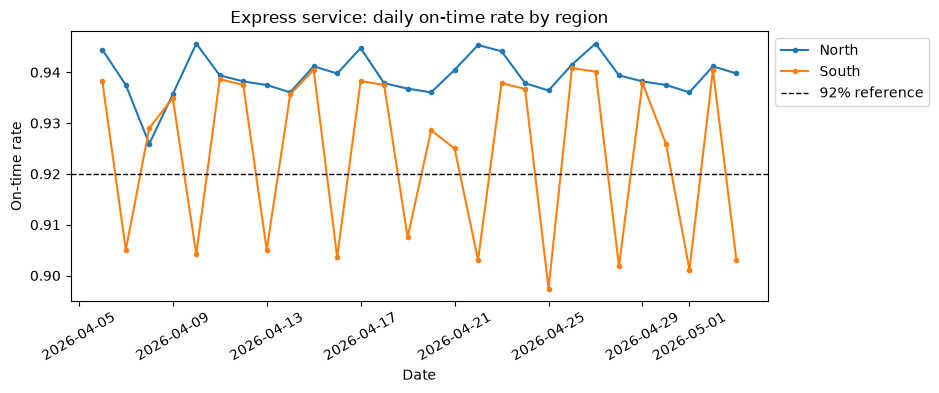

lines drawn: 3 | expected: 3


In [26]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for region in daily_express.columns:
    ax.plot(daily_express.index, daily_express[region], marker="o", markersize=3, label=region)
ax.axhline(0.92, color="black", linestyle="--", linewidth=1, label="92% reference")
ax.set(xlabel="Date", ylabel="On-time rate", title="Express service: daily on-time rate by region")
ax.tick_params(axis="x", labelrotation=30)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

print("lines drawn:", len(ax.lines), "| expected: 3")

**Answer to the second manager's question:** North's express service stayed above 92% on every day; South's fell below 92% on 10 of the 28 days.

### 2.12 Another way to organise the daily calculation

There is another valid way to build the daily express reliability table.

In the route above, we:

1. grouped the express observations in long format;
2. calculated the on-time rate for each date–region group;
3. reshaped those rates at the end.

We can also change the order slightly.

Instead of calculating the rate first, we can reshape the **counts** first.

We build:

- one table with dates in the rows, regions in the columns, and the total number of recorded parcels in each cell;
- one table with the same rows and columns, but containing the total number of on-time parcels.

We can create these two tables using:

```python
pivot_table(..., aggfunc="sum")
```

The first table might be called:

```python
daily_parcels
```

and the second:

```python
daily_on_time
```

Both tables have exactly the same structure:

- the same dates in the rows;
- the same regions in the columns.

We can then calculate:

```python
daily_express = daily_on_time / daily_parcels
```

Why does this work?

Because pandas aligns the two tables using their row and column labels, therefore the value for, say, a particular date in `North` is divided by the parcel total for that **same date and same region**. In other words, each cell is matched with the corresponding cell before the division is performed.

This route therefore follows the same principle as before:

**add up the parcel counts first → calculate the rate second**

The difference is only in how we organise the intermediate tables.

In [27]:
parcels_wide = express.pivot_table(index="date", columns="region", values="parcels", aggfunc="sum")
on_time_wide = express.pivot_table(index="date", columns="region", values="on_time_parcels", aggfunc="sum")
daily_express_b = on_time_wide / parcels_wide

assert np.allclose(daily_express_b.to_numpy(), daily_express.to_numpy())
print("Both ways give the same daily table.")
parcels_wide.head(3)

Both ways give the same daily table.


region,North,South
date,,
2026-04-06,180,162
2026-04-07,176,158
2026-04-08,81,155


This alternative route has one useful advantage: the numerator and denominator of every daily reliability rate remain visible in separate tables before we divide them.

The region–service summary from Step 5 still needs its own `groupby`, because it answers a different question.

### 2.13 From small tasks back to the full question

We started with one large data question.

By breaking it into smaller tasks, we can now see exactly how the dataset changes from one stage to the next:

```text
raw            224 x 6    original data; parcels read as text        Step 1
repaired       224 x 6    parcels numeric; 6 values become NaN       Step 2
analysis       218 rows   only rows with a recorded parcel count     Step 2
with_region    218 rows   region added                               Step 3
with_region    218 rows   on_time_parcels added                      Step 4
summary          4 rows   totals by region and service               Step 5
summary          4 rows   on_time_rate added                         Step 6
express        109 rows   express observations only                  Step 7a
express_daily   56 rows   one row per date and region                Step 7b
daily_express  28 x 2     dates in rows, regions in columns          Step 7c
days_below_92            days below the 92% reference level          Step 8
figure                    daily regional express reliability          Step 9
```

Each line represents a small and clearly defined task:

- we start from one object;
- we perform one operation;
- we create or update one object;
- we check that the result makes sense.

The full solution is therefore not one large piece of code.

It is a sequence of small steps that we can understand, test and correct one at a time.

### 3. What to do when you receive a larger coding task

When a coding task looks large, do not try to write the whole program at once.

Instead, turn the question into a sequence of smaller tasks.

1. **What information do you start from?**  
   Identify the inputs. Be precise about what one position, one row, or one key represents.

2. **What must you produce?**  
   List the required outputs and their form. For example:
   - one number;
   - a list that must preserve a particular order;
   - a dictionary keyed by employee name;
   - a table with one row per date and one column per region;
   - a figure.

3. **Work backwards from the outputs.**  
   For each final output, ask:

   **What information must already exist before I can produce this?**

   Keep asking that question until you reach the data you already have.

4. **Turn the reasoning into a sequence of tasks.**  
   For each step, write:

   **Input → Task → Output → Check**

   Try to give each step one clear purpose and one clearly identifiable result.

5. **Choose the Python tool that matches the task.**  
   Do not start from the syntax. First decide what you need to do, then choose an appropriate tool from the ones you already know.

6. **Code one task at a time.**  
   Run the code, inspect the result, and perform the check for that step before moving to the next one.

7. **If something goes wrong, use the checks to locate the problem.**  
   If Step 3 passed its checks but Step 4 did not, you know where to start looking. You do not need to debug the entire program at once.

A useful rule of thumb is that a step may be too large if:

- you cannot clearly say what it produces;
- you do not know how to check whether it worked;
- the code is doing several different jobs at once;
- the cell has become long enough that it is difficult to explain what each part is doing.

For these exercises, a cell longer than roughly 15 lines is often a sign that the task could be divided into smaller pieces.

### A quick guide: from the task to the Python tool

| When the task says… | Consider… |
|---|---|
| check that something is true | `assert` |
| check lengths or look for duplicates | `len()`, `set()` |
| go through several aligned lists together | `zip()` + `for` |
| decide one case using rules in a particular order | a function with `if / elif / else` and `return` |
| calculate a total or count for each key using Python objects | a dictionary updated inside a `for` loop |
| keep only the items that satisfy a condition, while preserving their order | a list comprehension with `if` |
| keep a separate copy that should not change when another object changes | `.copy()` |
| convert a text column that should contain numbers | `pd.to_numeric(..., errors="coerce")` or `na_values=...` |
| keep only rows that satisfy a condition | `.loc[condition]`, `.isin()` |
| add information from a lookup table | `merge(..., validate=...)` |
| calculate totals for each group | `groupby(...).agg(...)` or `.sum()` |
| create a table with one row per X and one column per Y | `pivot()` / `pivot_table()` |
| compare several series over time | `fig, ax = plt.subplots()`, `ax.plot()`, `ax.axhline()` |

The main idea is simple:

**understand the output → break the problem into tasks → choose the tool → code one task → check it → continue.**

## Part II — Your turn

You will now work on three new exercises.

Each exercise should take about **30-35'**, and all of them can be solve with Python tools introduced in Sessions 1 and 2.

The amount of guidance will gradually decrease from one exercise to the next.

| | What guidance do you receive? |
|---|---|
| Exercise 1 | You are given the goal, **the Python tool to use**, the object to create, and a check. |
| Exercise 2 | For the first tasks, you are told which Python tool to use. In the later tasks, you are told what object you need to create, but you choose the tool yourself. |
| Exercise 3 | You first write your own plan. For each task, you are told what object to create and how to check it, but you choose the Python tools yourself. |

The objective is not to solve the whole exercise at once.

In each exercise, you will move gradually from:

**one operation → a few connected operations → a short final result**

Work through the tasks in order. After each task, run the corresponding check cell before continuing.

If a check fails, start by looking at the code for the task immediately above it. The earlier checks have already helped you verify the previous parts of the solution.

### Exercise 1 — Processing account transactions in order

**Context**

A payment app receives ten transaction instructions for three prepaid accounts.

The instructions must be processed **in the order in which they were received**, because each accepted instruction changes the account balance that the next instruction will see.

For each instruction, apply the following rules in order:

1. If the amount is zero or negative, reject the instruction.
2. If the transaction kind is neither `"deposit"` nor `"withdrawal"`, reject the instruction.
3. If the instruction is a withdrawal and the amount is greater than the account's **current balance**, reject it.
4. Otherwise, accept the instruction:
   - a deposit increases the balance;
   - a withdrawal decreases the balance.

If an instruction is rejected, the account balance does not change.

**Final objective**

By the end of the exercise, your program should produce:

- one record for each instruction, kept in the original order;
- for each instruction, its status and the account balance immediately after it has been processed;
- the final balance of each account;
- the instructions that were rejected;
- a check showing that each final balance can be reconstructed from the accepted transactions;
- the account with the largest final balance.

The important feature of this exercise is that the instructions are **sequential**.

A withdrawal cannot be assessed using only the starting balance. It must use the balance that exists **at that point in the sequence**, after all earlier accepted instructions for that account have been processed.

In [28]:
opening_balances = {"Nadia": 120.0, "Omar": 40.0, "Iris": 0.0}

tx_ids = ["T01", "T02", "T03", "T04", "T05", "T06", "T07", "T08", "T09", "T10"]
tx_accounts = ["Nadia", "Omar", "Iris", "Omar", "Omar",
               "Nadia", "Iris", "Iris", "Nadia", "Nadia"]
tx_kinds = ["withdrawal", "withdrawal", "deposit", "deposit", "withdrawal",
            "deposit", "transfer", "withdrawal", "withdrawal", "deposit"]
tx_amounts = [50.0, 60.0, 80.0, 30.0, 60.0,
              -20.0, 25.0, 80.0, 75.0, 15.0]

#### Task 1.1 — Verify the inputs

Before processing any transaction, check that the input data are consistent.

**Goal:** make sure the four lists can be used together safely.

**Use:** `assert`, `len()`, `set()`, and then a `for` loop with `in`.

**Create:** no new data object.

Check the following three conditions:

1. the four lists have the same length;
2. every transaction ID is unique;
3. every account name appearing in `tx_accounts` is also present in `opening_balances`.

Why do these checks matter?

- If the lists have different lengths, the entries in the same position may no longer describe the same transaction.
- If a transaction ID appears more than once, we can no longer treat it as a unique identifier.
- If an account appears in `tx_accounts` but not in `opening_balances`, we do not know what balance that account should start from.

**Check:** the cell should finish without raising an `AssertionError`.

If an `AssertionError` appears, inspect which of the three assumptions is not satisfied before continuing.

In [29]:
# Task 1.1 

#### Task 1.2 — Decide one instruction

Now focus on **one transaction only**.

**Goal:** write the four transaction rules once, so that the same logic can later be reused for all ten instructions.

**Use:** a function called:

```python
apply_transaction(balance, kind, amount)
```

Inside the function, use `if / elif / else` to apply the rules in the correct order. The function should **return** a tuple.

**Create:** `apply_transaction`, returning:

```python
(status, new_balance)
```

where:

- `status` is either `"accepted"` or `"rejected"`;
- `new_balance` is the balance after the instruction has been assessed.

If the instruction is rejected, `new_balance` should be equal to the original `balance`.

Before writing the function, think carefully about the order of the rules.

For example, an invalid amount should be rejected *before Python ever considers* whether the instruction is a deposit or a withdrawal.

**Check:** the next cell will test the function on five cases whose answers can be worked out directly from the rules.

| balance | kind | amount | expected result |
|---|---|---|---|
| 100.0 | `deposit` | 20.0 | `("accepted", 120.0)` |
| 30.0 | `withdrawal` | 50.0 | `("rejected", 30.0)` |
| 30.0 | `withdrawal` | 30.0 | `("accepted", 0.0)` |
| 30.0 | `deposit` | −5.0 | `("rejected", 30.0)` |
| 30.0 | `transfer` | 10.0 | `("rejected", 30.0)` |

If one of these checks fails, correct the function before moving on to the full sequence of transactions.

In [30]:
def apply_transaction(balance, kind, amount):
    """Return (status, new_balance) for one instruction."""
    pass  # TODO: replace pass with your if / elif / else rules

In [31]:
# Check for Task 1.2
if apply_transaction(100.0, "deposit", 20.0) is None:
    print("Not attempted yet.")
else:
    assert apply_transaction(100.0, "deposit", 20.0) == ("accepted", 120.0)
    assert apply_transaction(30.0, "withdrawal", 50.0) == ("rejected", 30.0)
    assert apply_transaction(30.0, "withdrawal", 30.0) == ("accepted", 0.0)
    assert apply_transaction(30.0, "deposit", -5.0) == ("rejected", 30.0)
    assert apply_transaction(30.0, "transfer", 10.0) == ("rejected", 30.0)
    print("All five tests passed.")

Not attempted yet.


#### Task 1.3 — Try the first two instructions

Before writing a loop, connect the transaction data to the function you created in Task 1.2.

**Goal:** make sure you know how to take one instruction from the input lists, find the correct current balance, and pass the information to `apply_transaction()`.

**Use:** list indexing, such as:

```python
tx_accounts[0]
tx_kinds[0]
tx_amounts[0]
```

together with:

```python
opening_balances[...]
```

to obtain the starting balance of the relevant account.

**Create:** no new data yet.

For now, simply apply the function to the first two instructions and print the results.

Before running the code, write your expected answers for `T01` and `T02` as comments. Then run the function and compare Python's output with your hand calculation. 

If they do not, stop here and decide whether the problem comes from:

- the way you selected the transaction information;
- the balance you passed to the function;
- or the logic inside `apply_transaction()`.

In [32]:
# Task 1.3
# T01 expected: ...
# T02 expected: ...

#### Task 1.4 — Process all instructions in order

We are now ready to process the full sequence of transactions.

The important point is that each accepted instruction changes the balance that the next instruction for that account will see.

**Goal:** apply the transaction rules to all ten instructions, in order, while carrying each account's updated balance from one instruction to the next.

**Use:**

1. Start by creating:

```python
balances = opening_balances.copy()
```

We use `.copy()` because `balances` will change as the transactions are processed. Why? (Task 1.6).

2. Use `zip()` with a `for` loop to move through:

```python
tx_ids
tx_accounts
tx_kinds
tx_amounts
```

together. At each iteration, these four values describe one complete transaction.

3. Inside the loop:

   - read the account's **current** balance from `balances`;
   - call `apply_transaction()` using that balance, the transaction kind and the amount;
   - receive the `status` and `new_balance`;
   - update that account's value in `balances` with `new_balance`.

4. After assessing the instruction, create one dictionary describing what happened and append it to `tx_results`.

**Create:**

- `balances`, containing the current balance of each account as the transactions are processed;
- `tx_results`, containing one dictionary for each of the ten instructions, in their original order.

Each dictionary in `tx_results` should contain:

```python
{
    "tx_id": ...,
    "account": ...,
    "kind": ...,
    "amount": ...,
    "status": ...,
    "balance_after": ...
}
```

The key idea is that `balances` changes during the loop, while `opening_balances` does not: i) if an instruction is accepted, the corresponding balance changes; ii) if an instruction is rejected, `apply_transaction()` returns the same balance, so the account balance remains unchanged.

**Check:** run the next cell to verify that the ten instructions were processed correctly and in the correct order.

In [33]:
balances = None     # replace None: a copy of opening_balances
tx_results = None   # replace None: an empty list, then fill it with your loop

# TODO: your zip() + for loop here

In [34]:
# Check for Task 1.4
if balances is None or tx_results is None:
    print("Not attempted yet.")
else:
    assert [record["tx_id"] for record in tx_results] == tx_ids      # one record per ID, same order
    for record in tx_results:
        assert set(record) == {"tx_id", "account", "kind", "amount", "status", "balance_after"}
        assert record["status"] in ("accepted", "rejected")
        assert record["balance_after"] >= 0
    assert balances is not opening_balances                          # a copy, not the same dictionary
    assert opening_balances == {"Nadia": 120.0, "Omar": 40.0, "Iris": 0.0}
    print("Task 1.4 checks passed.")

Not attempted yet.


#### Task 1.5 — Summarise the rejections

We have now processed all ten instructions and stored the result of each one in `tx_results`. The next task is to summarise the rejected transactions.

**Goal:** count how many rejected instructions each account has, and collect the IDs of all rejected instructions.

**Use:**

- a dictionary and a `for` loop over `tx_results` to build `rejected_by_account`;
- a list comprehension with `if` to build `rejected_ids`.

Start by creating one entry for every account in `opening_balances`, with a rejection count of `0`.

This is important because an account with no rejected instructions should still appear in the final dictionary.

For example, the starting structure should look like:

```python
{
    "Account_A": 0,
    "Account_B": 0,
    "Account_C": 0
}
```

Then loop through `tx_results`.

For each transaction:

1. check whether its `status` is `"rejected"`;
2. if it is, add `1` to the rejection count of the corresponding account.

This gives us:

```python
rejected_by_account
```

which maps each account to its number of rejected instructions.Next, create:

```python
rejected_ids
```

using a list comprehension with an `if` condition. Keep only the transaction IDs whose status is `"rejected"`.

Because `tx_results` is already in input order, the resulting list of IDs will also remain in input order.

**Create:**

- `rejected_by_account`: account → number of rejected instructions;
- `rejected_ids`: the IDs of rejected instructions, in their original order.

**Check:** run the next cell to verify both objects.

In [35]:
rejected_by_account = None   # replace None
rejected_ids = None          # replace None

In [36]:
# Check for Task 1.5
if rejected_by_account is None or rejected_ids is None:
    print("Not attempted yet.")
else:
    assert set(rejected_by_account) == set(opening_balances)      # every account appears
    assert sum(rejected_by_account.values()) == len(rejected_ids)
    assert rejected_ids == [tx_id for tx_id in tx_ids if tx_id in rejected_ids]   # input order
    print("Task 1.5 checks passed.")

Not attempted yet.


#### Task 1.6 — Reconcile and answer

We have reached the final stage of the exercise.

Before answering the last management question, we first want to check that the final balances are consistent with the transactions we processed.

**Goal:** recompute each final balance in a different way, compare it with `balances`, and then identify the account with the largest final balance.

---

**1. Recompute the final balances**

Create a new dictionary called:

```python
recomputed
```

Start from the original `opening_balances`. Then loop through `tx_results`. For each transaction:

- ignore it if its `status` is `"rejected"`;
- if it is an accepted deposit, add the amount;
- if it is an accepted withdrawal, subtract the amount.

Use only:

```python
opening_balances
tx_results
```

for this calculation. Do **not** use `balances`. Why?

Because the purpose of this step is to check `balances` independently.

If we used `balances` to reconstruct `balances`, the check would tell us very little.

The logic is:

**opening balance + accepted deposits − accepted withdrawals = final balance**

You can reuse the dictionary-and-loop pattern from Task 1.5.

---

**2. Find the account with the largest final balance**

Create:

```python
richest_account
```

using the final values in `balances`:

- loop through the dictionary with `.items()`;
- keep track of the largest balance seen so far;
- keep the account associated with that balance.

**Create:**

- `recomputed`, containing one independently reconstructed final balance per account;
- `richest_account`, the account with the largest final balance.

**Check:** run the next cell to compare `recomputed` with `balances`.

If the two dictionaries agree, the final balances have been obtained in two different ways and give the same result.

In [37]:
recomputed = None        # replace None
richest_account = None   # replace None

In [38]:
# Check for Task 1.6
if recomputed is None or richest_account is None:
    print("Not attempted yet.")
else:
    for account in opening_balances:
        assert abs(recomputed[account] - balances[account]) < 1e-9, f"{account} does not reconcile"
    assert richest_account in opening_balances
    print("Every final balance reconciles.")
    print("Rejected:", rejected_ids, "| largest final balance:", richest_account)

Not attempted yet.


### Exercise 2 — Valuing a small portfolio from daily prices

**Context**

An investment club holds shares in four stocks. The file:

```python
data/session4_portfolio_prices.csv
```

contains the daily prices of those stocks over 20 trading days. Each row contains:

- `date`;
- `ticker`;
- `close`.

The number of shares held in each stock is given in the `holdings` table below. For two observations, the closing price was not received. In those rows, the file contains:

```python
no_quote
```

instead of a price. For each stock on each date:

```text
position value = closing price × number of shares held
```

The total value of the portfolio on a date is therefore:

```text
portfolio value = sum of the four position values on that date
```

There is one important rule: if the price of **even one stock** is missing on a particular date, we cannot calculate the value of the complete portfolio on that date.

We must therefore remove that date **for all four stocks**, not only remove the row containing `no_quote`.

**Final objective**

By the end of the exercise, your analysis should produce:

- the total portfolio value for every date on which all four prices are available;
- the number of complete dates on which the portfolio value is below its value on the first complete date;
- the contribution of each stock to the change in portfolio value between the first and the last complete date;
- one figure showing how the portfolio value changes over time.

The important idea in this exercise is that a problem in **one row** can affect whether an **entire date** can be used.

In [39]:
holdings = pd.DataFrame({
    "ticker": ["NOVA", "LUMA", "PINE", "ORCA"],
    "shares": [40, 120, 60, 25],
})
holdings

,ticker,shares
0,NOVA,40
1,LUMA,120
2,PINE,60
3,ORCA,25


#### Task 2.1 — Load and inspect the price data

Before calculating any portfolio values, first look at the dataset as pandas has read it.

**Goal:** understand the shape of the table, the type of each column, and whether anything needs to be repaired before we can calculate with the prices.

**Use:**

```python
pd.read_csv(PRICES_PATH, parse_dates=["date"])
```

Then inspect the result using:

```python
.shape
.dtypes
.head()
```

**Create:** `raw_prices`.

Remember what we expect from the data:

- 4 stocks;
- 20 trading days;
- one row for each date–ticker combination.

So the complete file should contain:

```text
4 × 20 = 80 rows
```

and 3 columns:

```text
date, ticker, close
```

**Check:** confirm that `raw_prices` has 80 rows and 3 columns. Then inspect the column types (one column has been read as text? Which column is it?).

In [40]:
raw_prices = None   # replace None: load the file

In [41]:
# Check for Task 2.1
if raw_prices is None:
    print("Not attempted yet.")
else:
    print("shape:", raw_prices.shape, "| expected: (80, 3)")
    print(raw_prices.dtypes)

Not attempted yet.


#### Task 2.2 — Repair the prices

The `close` column contains the text `no_quote`. We now need to repair that column before using it in any valuation calculation.

**Goal:** create a numeric `close` column, with every `no_quote` entry represented as a missing value.

**Use:**

Start from a copy of the original table:

```python
prices = raw_prices.copy()
```

Then convert the `close` column with:

```python
pd.to_numeric(..., errors="coerce")
```

The option:

```python
errors="coerce"
```

tells pandas to convert valid prices to numbers and replace anything that cannot be interpreted as a number with `NaN`.

So every `no_quote` entry becomes a missing value.

**Create:** `prices`.

At this stage, keep all 80 rows. We are only repairing the price column; we have not yet decided which dates can be used for portfolio valuation.

**Check:** compare:

- the number of `no_quote` entries in `raw_prices`;
- the number of missing values in `prices["close"]`.

These two numbers should be the same.

If they are not, inspect the conversion before moving to the next task.

In [42]:
prices = None   # replace None

In [43]:
# Check for Task 2.2
if prices is None:
    print("Not attempted yet.")
else:
    n_markers = (raw_prices["close"] == "no_quote").sum()
    print("close dtype:", prices["close"].dtype)
    print("missing closes:", prices["close"].isna().sum(), "| no_quote markers:", n_markers)
    assert prices["close"].isna().sum() == n_markers

Not attempted yet.


#### Task 2.3 — Remove the incomplete dates

We now know which individual rows have a missing closing price.

But the rule applies at the **date level**: if even one stock is missing a price on a given date, that entire date cannot be used to value the portfolio.

So this task has two connected parts.

**Goal:** identify the incomplete dates, then remove all rows belonging to those dates.

**Use:**

1. Find the dates where `close` is missing.

Use `.loc[]` together with `.isna()` to select the `date` values from those rows. Store the result in:

```python
bad_dates
```

2. Remove every row whose date appears in `bad_dates`.

Use:

```python
.isin(bad_dates)
```

to identify those rows, and `~` to reverse the condition so that we keep only dates that are **not** in `bad_dates`. Store the result in:

```python
complete
```

**Create:**

- `bad_dates`, containing the dates with at least one missing closing price;
- `complete`, containing only dates for which all four stock prices are available.

Why do we remove the whole date? Because the portfolio value for a date requires the value of all four positions. Keeping the three available stocks and ignoring the missing one would give the value of an incomplete portfolio.

**Check:**

- `complete["close"]` should contain no missing values;
- every remaining date should appear exactly 4 times, once for each stock.

If a remaining date has fewer than 4 rows, then the portfolio for that date is still incomplete.

In [44]:
bad_dates = None   # replace None
complete = None    # replace None

In [45]:
# Check for Task 2.3
if complete is None:
    print("Not attempted yet.")
else:
    rows_per_date = complete.groupby("date").size()
    assert complete["close"].notna().all(), "a missing close is still there"
    assert (rows_per_date == 4).all(), "some dates do not have all four stocks"
    print("complete dates:", complete["date"].nunique(), "| rows:", len(complete))

Not attempted yet.


#### Task 2.4 — Value each position

We now have only complete dates, but each row still contains only the stock price.

To calculate the value of each position, we also need to know how many shares of that stock the investment club holds.

**Goal:** attach the number of shares to every price observation, then calculate the value of each position.

**Use:**

Merge `complete` with the `holdings` table using:

```python
on="ticker"
how="left"
validate="many_to_one"
```

This is the same type of merge we used in Part I:

- many price observations can belong to the same ticker;
- each ticker should appear only once in `holdings`, with one number of shares.

After the merge, calculate:

```python
position_value = close * shares
```

using column arithmetic.

**Create:** `valued`, containing two new columns:

- `shares`;
- `position_value`.

Each row now tells us not only the stock price, but also the value of the club's position in that stock on that date.

**Check:**

- `valued` should have the same number of rows as `complete`;
- `shares` should contain no missing values.

If `shares` contains a missing value, then at least one ticker in the price data did not find a match in the `holdings` table.

In [46]:
valued = None   # replace None

In [47]:
# Check for Task 2.4
if valued is None:
    print("Not attempted yet.")
else:
    assert len(valued) == len(complete)
    assert valued["shares"].notna().all()
    assert "position_value" in valued.columns
    print("Task 2.4 checks passed.")

Not attempted yet.


#### Task 2.5 — One row per date, one column per stock

We now have one row for each stock on each complete date, together with its `position_value`.

The next step is to reorganise these values into a table that is easier to use for portfolio calculations.

**Goal:** create a table with:

- one row for each date;
- one column for each ticker;
- the corresponding `position_value` in each cell.

You built this kind of table in Part I. Decide which pandas tool is appropriate here.

**Create:** `wide`.

The structure should look conceptually like this:

```text
ticker       Stock A    Stock B    Stock C    Stock D
date
date 1         ...        ...        ...        ...
date 2         ...        ...        ...        ...
date 3         ...        ...        ...        ...
```

**Check:**

- `wide` has one row for every date in `complete`;
- `wide` has 4 columns, one for each stock;
- there are no missing values;
- the first row corresponds to the earliest date.

In [48]:
wide = None   # replace None

In [49]:
# Check for Task 2.5
if wide is None:
    print("Not attempted yet.")
else:
    assert wide.shape == (complete["date"].nunique(), 4)
    assert not wide.isna().any().any()
    assert wide.index[0] == complete["date"].min()
    print("wide:", wide.shape)

Not attempted yet.


#### Task 2.6 — Daily portfolio value, computed two ways

We now have the value of each individual position on every complete date.

The next step is to combine the four positions into one total portfolio value for each date.

**Goal:** calculate one portfolio value per date, and calculate it in two different ways.

**Create:**

- `portfolio_value`: start from `wide` and add the four position values across each row;
- `portfolio_value_check`: start again from `valued` and obtain one total per date using a different pandas operation.

The two objects should represent exactly the same quantity:

```text
portfolio value on a date = sum of the four position values on that date
```

Why calculate it twice? Because the second calculation gives us an independent check of the first one. 

**Check:**

- both objects contain one value for each complete date;
- the dates correspond;
- the values agree, using `np.allclose()`.

If the two calculations disagree, do not continue.

In [50]:
portfolio_value = None         # replace None
portfolio_value_check = None   # replace None

In [51]:
# Check for Task 2.6
if portfolio_value is None or portfolio_value_check is None:
    print("Not attempted yet.")
else:
    assert len(portfolio_value) == len(wide)
    assert np.allclose(np.asarray(portfolio_value), np.asarray(portfolio_value_check))
    print("Both calculations agree.")

Not attempted yet.


#### Task 2.7 — Days below the starting value and each stock's contribution

We now have the daily portfolio value and the position value of each stock on every complete date.

**Goal:** calculate:

- how often the portfolio falls below its value on the first complete date;
- how much each stock contributes to the change in portfolio value between the first and the last complete date.

**Create:**

- `days_below`: the number of dates on which `portfolio_value` is smaller than its value on the **first** date;
- `contributions`: one value per ticker, calculated as:

```text
position value on the last date − position value on the first date
```

The contribution is therefore positive if that stock's position value increased between the first and last date, and negative if it decreased.

**Check:** the four stock contributions should add up to the total change in portfolio value between the first and the last complete date.

In other words:

```text
sum of stock contributions
=
portfolio value on last date − portfolio value on first date
```

In [52]:
days_below = None      # replace None
contributions = None   # replace None

In [53]:
# Check for Task 2.7
if days_below is None or contributions is None:
    print("Not attempted yet.")
else:
    daily_values = portfolio_value.tolist()
    change = daily_values[-1] - daily_values[0]
    assert len(contributions) == 4
    assert np.isclose(contributions.sum(), change)
    print("Contributions add up to the portfolio change.")

Not attempted yet.


#### Task 2.8 — Figure and final answer

The last step is to present the result visually and briefly interpret it.

**Goal:** compare the daily portfolio value with its value on the first complete date.

**Create:**

one figure containing:

- the daily `portfolio_value` as a line;
- a dashed horizontal reference line at the portfolio value on the first date;
- a label for the horizontal axis;
- a label for the vertical axis;
- a title;
- a legend.

Your answer should use the results you have already calculated, including:

- `days_below`;
- the stock contributions to the change from the first to the last date.

**Check:** the figure should contain two lines:

1. the daily portfolio value;
2. the horizontal line showing the starting value.

lines drawn: 0 | expected: 2


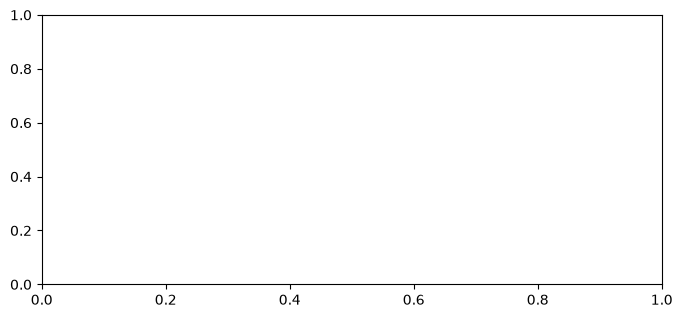

In [54]:
fig, ax = plt.subplots(figsize=(8, 3.5))

# TODO: your plotting code here

print("lines drawn:", len(ax.lines), "| expected: 2")
plt.show()

**Your answer:** 

### Exercise 3 — Choosing the cheapest mobile plan

**Context**

A company pays the mobile plans of six employees.

There are three available plans. Each plan has:

- a monthly `fee`;
- an amount of data included in the fee, `included_gb`;
- an additional cost per GB above that allowance, `extra_per_gb`.

For one month:

```text
monthly cost
=
fee + extra_per_gb × GB used above the allowance
```

If usage stays within the included allowance, the extra charge is zero.

The table `usage` gives each employee's data use in January, February and March.

The dictionary `current_plan` gives the plan currently assigned to each employee.

**Final objective**

For each employee, find:

- the plan that would have been cheapest over the three months;
- the saving compared with the employee's current plan.

Then produce:

- the list of employees who should switch;
- the company's total potential saving;
- a bar chart showing the saving for each employee.

In [55]:
plans = {
    "Basic": {"fee": 8.0, "included_gb": 5, "extra_per_gb": 2.0},
    "Plus": {"fee": 15.0, "included_gb": 15, "extra_per_gb": 1.5},
    "Max": {"fee": 25.0, "included_gb": 40, "extra_per_gb": 1.0},
}

usage = pd.DataFrame({
    "employee": ["Ana", "Ben", "Chen", "Dara", "Eli", "Femi"] * 3,
    "month": ["Jan"] * 6 + ["Feb"] * 6 + ["Mar"] * 6,
    "gb": [3, 12, 30, 6, 16, 22,
           4, 18, 45, 9, 14, 25,
           2, 10, 38, 7, 20, 19],
})

current_plan = {"Ana": "Basic", "Ben": "Max", "Chen": "Plus",
                "Dara": "Plus", "Eli": "Plus", "Femi": "Plus"}
usage.head(7)

,employee,month,gb
0,Ana,Jan,3
1,Ben,Jan,12
2,Chen,Jan,30
3,Dara,Jan,6
4,Eli,Jan,16
5,Femi,Jan,22
6,Ana,Feb,4


#### Task 3.0 — Plan your tasks

*Write your plan here.*

#### Task 3.1 — One month, one plan

**Task:** write the cost rule for one month.

**Create:** a function:

```python
monthly_cost(plan, gb)
```

where `plan` is one of the plan dictionaries, for example:

```python
plans["Basic"]
```

The function should return:

```text
monthly fee + any extra data charge
```

If usage is within the included allowance, the extra charge is zero.

**Check:** the next cell should confirm:

- Basic, 4 GB → `8.0`
- Basic, 8 GB → `14.0`
- Plus, 15 GB → `15.0`
- Max, 41 GB → `26.0`

In [56]:
def monthly_cost(plan, gb):
    pass  # TODO

In [57]:
# Check for Task 3.1
if monthly_cost(plans["Basic"], 4) is None:
    print("Not attempted yet.")
else:
    assert monthly_cost(plans["Basic"], 4) == 8.0
    assert monthly_cost(plans["Basic"], 8) == 14.0
    assert monthly_cost(plans["Plus"], 15) == 15.0
    assert monthly_cost(plans["Max"], 41) == 26.0
    print("All four tests passed.")

Not attempted yet.


#### Task 3.2 — Every month under every plan

**Task:** calculate what each employee-month would cost under each of the three plans.

Add three new columns to `usage`:

```python
"Basic"
"Plus"
"Max"
```

Each column should contain the monthly cost under that plan.

**Create:** three new cost columns in `usage`.

**Check:**

- the three plan columns exist;
- `usage` still has 18 rows;
- no cost is missing;
- no monthly cost is below that plan's monthly fee.

In [58]:
# Task 3.2 — add the three cost columns to usage

In [59]:
# Check for Task 3.2
missing_columns = [name for name in plans if name not in usage.columns]
if missing_columns:
    print("Not attempted yet. Missing columns:", missing_columns)
else:
    assert len(usage) == 18
    for name, plan in plans.items():
        assert usage[name].notna().all()
        assert (usage[name] >= plan["fee"]).all(), f"a {name} cost is below its fee"
    print("Task 3.2 checks passed.")

Not attempted yet. Missing columns: ['Basic', 'Plus', 'Max']


#### Task 3.3 — Three-month total per employee

**Task:** add together January, February and March for each employee, separately for each plan.

**Create:** `totals`, a table with:

- one row per employee;
- one column for each plan.

Each cell should contain that employee's total three-month cost under that plan.

**Check:**

- `totals` has 6 rows;
- `totals` has 3 columns;
- the sum of all values in `totals` equals the sum of the three plan-cost columns in `usage`.

In [60]:
totals = None   # replace None

In [61]:
# Check for Task 3.3
if totals is None:
    print("Not attempted yet.")
else:
    assert totals.shape == (usage["employee"].nunique(), len(plans))
    assert set(totals.columns) == set(plans)
    assert np.isclose(totals.to_numpy().sum(), usage[list(plans.keys())].to_numpy().sum())
    print("Task 3.3 checks passed.")

Not attempted yet.


#### Task 3.4 — The cheapest plan for each employee

**Task:** for each employee, find the plan with the lowest three-month cost and the value of that cost.

**Create:** `report`, a table with:

- one row per employee, with employee names as the index;
- a `best_plan` column;
- a `best_cost` column.

**Check:**

- `best_cost` equals the cost of `best_plan` for that employee in `totals`;
- `best_cost` is not greater than the cost of any of the three plans for that employee.

In [62]:
report = None   # replace None

In [63]:
# Check for Task 3.4
if report is None:
    print("Not attempted yet.")
else:
    for employee in totals.index:
        best_plan = report.loc[employee, "best_plan"]
        assert best_plan in plans
        assert report.loc[employee, "best_cost"] == totals.loc[employee, best_plan]
        assert report.loc[employee, "best_cost"] <= totals.loc[employee].min()
    print("Task 3.4 checks passed.")

Not attempted yet.


#### Task 3.5 — Compare with the current plan

**Task:** compare the cheapest plan with the plan each employee currently has.

For each employee, add to `report`:

- the current plan;
- the three-month cost of that current plan;
- the saving from switching to the cheapest plan.

Calculate:

```text
saving = current cost − best cost
```

**Create:** three new columns in `report`:

- `current_plan`;
- `current_cost`;
- `savings`.

**Check:**

- no value in `savings` is negative;
- `savings` is `0` exactly when `best_plan` is the same as `current_plan`.

In [64]:
# Task 3.5 — add current_plan, current_cost and savings to report

In [65]:
# Check for Task 3.5
if report is None or "savings" not in report.columns:
    print("Not attempted yet.")
else:
    assert report["current_plan"].notna().all()
    assert (report["savings"] >= 0).all()
    assert ((report["savings"] == 0) == (report["best_plan"] == report["current_plan"])).all()
    print("Task 3.5 checks passed.")

Not attempted yet.


#### Task 3.6 — Final result

**Task:** use `report` to answer the management question.

**Create:**

- `switchers`: the list of employees whose `savings` are positive, keeping the same order as `report`;
- `total_savings`: the total three-month saving if all employees with a positive saving switch plans;
- a bar chart showing the saving for each employee, with axis labels and a title;
- one or two sentences in the Markdown cell below the chart summarising the result.

**Check:** the next cell should confirm that:

- `switchers` contains exactly the employees in `report` whose `savings` are positive;
- `total_savings` equals the sum of the `savings` column in `report`.

In [66]:
switchers = None       # replace None
total_savings = None   # replace None

In [67]:
# Check for Task 3.6
if switchers is None or total_savings is None:
    print("Not attempted yet.")
else:
    assert len(switchers) == (report["savings"] > 0).sum()
    assert np.isclose(total_savings, report.loc[switchers, "savings"].sum())
    print("Task 3.6 checks passed.")

Not attempted yet.


bars drawn: 0 | expected: 6


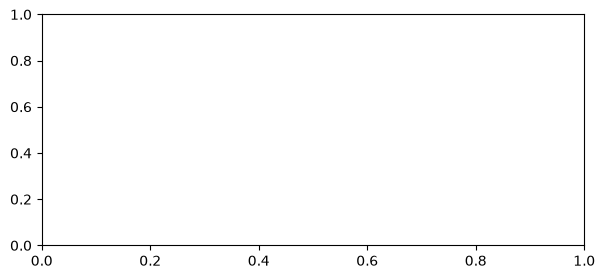

In [68]:
fig, ax = plt.subplots(figsize=(7, 3))

# TODO: your bar chart here

print("bars drawn:", len(ax.patches), "| expected: 6")
plt.show()

**Your answer:** 